# Assignments - Digital options

Create a new folder under <b>QuantCourseBP\homeworks</b> and copy over the content of this lecture's solution folder to start with.

1. Get familiar with digital options and implement EuropeanDigitalContract and EuropeanDigitalAnalyticPricer (fair value and greeks) in the library. Implement unit test for fair value using pytest. **(12 points)**
2. Get familiar with bull spread options and by utilizing EuropeanDigitalAnalyticPricer and EuropeanAnalyticPricer, create a figure to visualize that a digital call option can be thought of as a limit of bull spread call options. **(8 points)**

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from typing import Dict, List, Union

In [127]:
# Add current folder and QuantCourseBP folder to syspath to import modules
import sys
from pathlib import Path
current = Path(Path().resolve())
sys.path.append(str(current))
sys.path.append(str(current.parents[2]))

from enum import *
from pricer import *

In [128]:
und = Stock.BLUECHIP_BANK
d = EuropeanDigitalContract(und, PutCallFwd.CALL, LongShort.LONG, 100, 2, 5)

In [129]:
spot = {1: 95, 2: 102, 3: 100}
d.payoff(spot)

5.0

## Price and Greeks of Cash-or-Nothing European Digital Option:

Source of formulas: https://www.quantpie.co.uk/bsm_bin_c_formula/bs_bin_c_summary.php

Let
\begin{equation}
\phi = \begin{cases}
    1 & \text{if Call}\\
    -1 & \text{if Put}
\end{cases}
\end{equation}

Using this notation, we can compactly give the formulas for the greeks of both the call and put options in one table:

<table>
    <tr>
        <th>Greek</th><th>Formula</th>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \Delta = c'_S
            \end{equation} 
        </td>
        <td>
            \begin{equation}
                \frac{\phi e^{-r(T-t)}}{S_t \sigma \sqrt{T-t}} n(d_2)
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \mathcal{V} = c'_\sigma
            \end{equation}
        </td>
        <td>
            \begin{equation}
                - \frac{\phi e^{-r(T-t)}}{\sigma} n(d_2) d_1
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \Theta = c'_\tau
            \end{equation}
        </td>
        <td>
            \begin{equation}
                e^{-r(T-t) \left(\phi n(d_2) \frac{1}{2(T-t)} \frac{1}{\sigma \sqrt{T-t}} \left(log\left(\frac{S_t}{K}\right) - \left(r - \frac{\sigma^2}{2}\right) (T-t) \right) + r N(\phi d_2)\right)}
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \rho = c'_r
            \end{equation}
        </td>
        <td>
            \begin{equation}
                e^{-r(T-t)} \left( \frac{\phi \sqrt{T-t}}{\sigma} n(d_2) - (T-t) N(\phi d_2) \right)
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \Gamma = \Delta'_S = c''_{SS}
            \end{equation}
        </td>
        <td>
            \begin{equation}
                - \frac{\phi e^{-r(T-t)}}{S_t^2 \sigma^2 (T-t)} n(d_2) d_1
            \end{equation} 
        </td>
    </tr>
</table>

In [130]:
# some type hints in the header of the function
def my_plotter(x: List[float], y: Union[List[float], List[List[float]]], plot_kwargs: List[Dict] = None, layout: Dict = {}, names: List[str] = None) -> None:
    """ inline for loop is called 'list comprehension' """
    y = [y] if all(isinstance(item, float) for item in y) else y
    
    plt.figure(figsize=(8, 4))
    lines = []
    show_legend = True if names is not None else False
    # show_legend = True if names else False  -> here is fine, but be cautious bc 0, empty str and empty list will be evaulated to False

    """ setup some basic key-word arguments for plot line """
    plot_kwargs_0 = {
        'linestyle': 'solid',
        'linewidth': 2
    }
    if names is not None:
        show_legend = True
        if len(names) != len(y):
            raise ValueError("Length of names is not matching with number of plotted y lists.")

    """ 'enumerate' add a counter to the loop """
    for i, y_item in enumerate(y):
        if plot_kwargs is not None and plot_kwargs[i] is not None:
            if show_legend:
                plot_kwargs[i]['label'] = names[i]
            _line = plt.plot(x, y_item, **plot_kwargs[i])
        else:
            if show_legend:
                plot_kwargs_0['label'] = names[i]
            _line = plt.plot(x, y_item, **plot_kwargs_0)
        lines.append(_line)

    if show_legend:
        plt.legend(fontsize=10)
    if 'title' in layout:
        plt.title(layout['title'], fontsize=20)
        rcParams['axes.titlepad'] = 30 # moving the title a little further away from the plot
    if 'x_label' in layout:
        plt.xlabel(layout['x_label'], fontsize=16)
        rcParams['axes.labelpad'] = 20 # moving the ax label a little further away from the plot

    """ enhance axes """
    ax = plt.gca() # gca: get current axes
    ax.axhline(linestyle='--', color='black', linewidth=1)
    plt.show()

In [131]:
und = Stock.BLUECHIP_BANK
strike = 100
cash_payoff = 1

step_size = 0.001
x_stock_price = np.arange(99, 102, step_size)

d = EuropeanDigitalContract(und, PutCallFwd.CALL, LongShort.LONG, strike, 1, cash_payoff)
y_digital_payoff = np.array([d.payoff({1: x}) for x in x_stock_price])

spread = [1/2**i for i in range(0, 5)]
y_bullspread_payoff = []
names = ['digital']
for s in spread:
    vanilla_long = EuropeanContract(und, PutCallFwd.CALL, LongShort.LONG, strike, 1)
    vanilla_short = EuropeanContract(und, PutCallFwd.CALL, LongShort.SHORT, strike + s, 1)
    y_bullspread_payoff.append(1 / s * np.array([vanilla_long.payoff({1: x}) + vanilla_short.payoff({1: x}) for x in x_stock_price]))
    names += [f'{int(1/s)} bull spread with $s=1/{int(1/s)}$']
    
y_payoffs = [y_digital_payoff] + y_bullspread_payoff

print(names)

['digital', '1 bull spread with $s=1/1$', '2 bull spread with $s=1/2$', '4 bull spread with $s=1/4$', '8 bull spread with $s=1/8$', '16 bull spread with $s=1/16$']


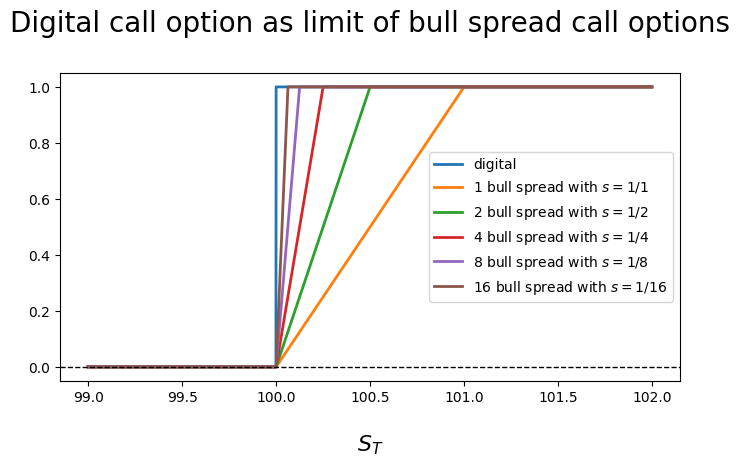

In [133]:
layout = {'title': 'Digital call option as limit of bull spread call options', 'x_label': '$S_{T}$', 'y_label': 'Payoff at time $T$'}
my_plotter(x_stock_price, y_payoffs, layout=layout, names=names)

In [6]:
!pytest

============================= test session starts =============================
platform win32 -- Python 3.9.13, pytest-7.4.2, pluggy-1.6.0
rootdir: C:\Users\marto\Egyetem\Pénzügyi árazási könyvtár\QuantCourseBP\homeworks\9387067\Homework
plugins: anyio-4.12.1
collected 144 items

test_pricer.py ......................................................... [ 39%]
........................................................................ [ 89%]
...............                                                          [100%]

============================= 144 passed in 0.50s =============================
